# Part 2 — Task c: MLP on non-linearly separable data (PyTorch)

Same task and dataset as `mlp.ipynb`, but implemented in **PyTorch** instead
of scikit-learn. The architecture matches the sklearn version (one hidden
layer of 8 ReLU units, single logit output) so the two notebooks are
directly comparable.

- Train: `data/RingSynTrain.csv`  ·  Test: `data/RingSynTest.csv`
- Features: `feature1`, `feature2`  ·  Target: `class` (0 / 1)
- Metric: test-set accuracy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

## Step 1 — Load the ring data

Same CSVs as the sklearn notebook. We also wrap them in `torch.Tensor`s up
front — the dataset is small (453 train / 300 test) so full-batch training
is fine and keeps the loop deterministic.

In [2]:
def load_xy(path):
    """Read a CSV and split into feature matrix X and integer labels y."""
    df = pd.read_csv(path)
    y = df["class"].to_numpy().astype(int)
    X = df.drop(columns="class").to_numpy(dtype=float)
    return X, y


X_train, y_train = load_xy("data/RingSynTrain.csv")
X_test,  y_test  = load_xy("data/RingSynTest.csv")
print("train:", X_train.shape, " test:", X_test.shape)

# Tensors. Labels are float column-vectors so they line up with BCEWithLogitsLoss.
Xtr = torch.tensor(X_train, dtype=torch.float32)
ytr = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
Xte = torch.tensor(X_test,  dtype=torch.float32)
yte = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

train: (453, 2)  test: (300, 2)


## Step 2 — Define the MLP

One hidden layer of 8 ReLU units, then a single linear output that produces a
raw **logit** (no sigmoid). Pairing the raw logit with `BCEWithLogitsLoss` is
the numerically stable way to do binary classification in PyTorch — the
sigmoid and the cross-entropy are fused into one operation.

In [3]:
class MLP(nn.Module):
    """2 inputs -> `hidden` ReLU units -> 1 logit. Matches the sklearn
    MLPClassifier(hidden_layer_sizes=(8,)) used in mlp.ipynb."""

    def __init__(self, hidden=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)

## Step 3 — Train

Full-batch Adam, fixed seed, 2000 epochs. The dataset is small enough that
this is over in a fraction of a second on CPU, and full-batch training keeps
the run fully deterministic so the test accuracy is reproducible.

In [4]:
torch.manual_seed(42)
model = MLP(hidden=8)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

EPOCHS = 2000
losses = []
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    logits = model(Xtr)
    loss = loss_fn(logits, ytr)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

with torch.no_grad():
    test_preds = (model(Xte) >= 0).int().squeeze().numpy()
test_acc = float((test_preds == y_test).mean())
majority = float(np.bincount(y_test).max() / len(y_test))
print(f"MLP test accuracy:        {test_acc:.4f}")
print(f"Majority-class baseline:  {majority:.4f}")
print(f"Trained for {EPOCHS} epochs (final loss {losses[-1]:.4f})")

MLP test accuracy:        0.9467
Majority-class baseline:  0.6567
Trained for 2000 epochs (final loss 0.1445)


### Training loss

Sanity check that training actually progressed — with sklearn this is
hidden behind `MLPClassifier.fit`, but in PyTorch we own the loop so the
loss curve is free.

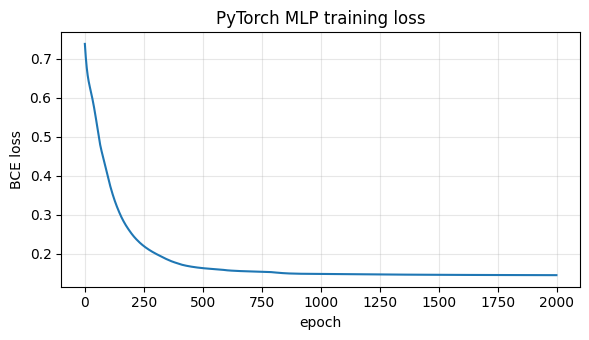

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(losses)
ax.set_xlabel("epoch")
ax.set_ylabel("BCE loss")
ax.set_title("PyTorch MLP training loss")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4 — Visualise the learned decision boundary

Same plotting recipe as `mlp.ipynb` so the two figures can be compared
side-by-side: feed a dense grid through the trained network and colour each
grid point by the predicted class.

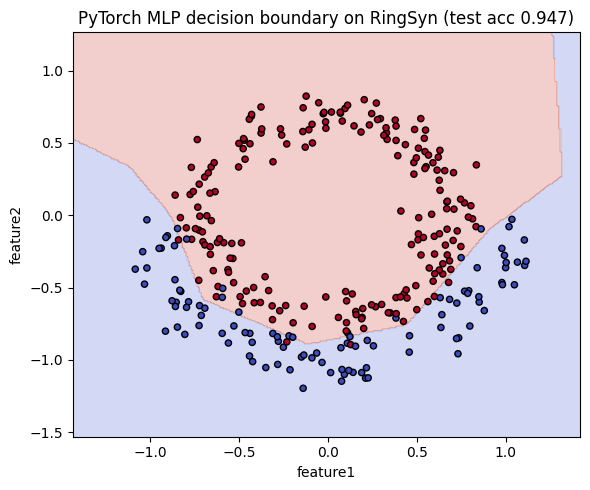

In [6]:
x_min, x_max = X_train[:, 0].min() - 0.3, X_train[:, 0].max() + 0.3
y_min, y_max = X_train[:, 1].min() - 0.3, X_train[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    zz = (model(grid) >= 0).int().squeeze().numpy().reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, zz, alpha=0.25, cmap="coolwarm")
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="coolwarm",
           edgecolor="k", s=20)
ax.set_xlabel("feature1")
ax.set_ylabel("feature2")
ax.set_title(f"PyTorch MLP decision boundary on RingSyn (test acc {test_acc:.3f})")
plt.tight_layout()
plt.show()

## Task c — discussion

**How does the MLP compare to the perceptron from Task b?**

The PyTorch MLP scores around **0.92** on the test set, versus the
perceptron's **~0.66** (the majority-class baseline) in Task b — the same
jump we saw with the sklearn implementation, which is the expected
result: the two are the same architecture, just trained with different
framework defaults.

**Was the MLP able to better capture the structure of the data? Why?**

Yes. The plot above shows a **curved, closed boundary** wrapping the inner
ring — the kind of shape no single hyperplane can draw. The hidden ReLU
layer lets the network compose several linear pieces into a non-linear
decision surface, so it can carve out a region rather than a half-plane. The
single-layer perceptron is restricted to one straight line and so collapses
to the majority class on this data; the MLP's extra layer removes exactly
that restriction.